# 🩺 Skin Disease Detection — Transfer Learning (Kaggle Edition)

---

## Project Overview

Multi-class skin disease classification using **EfficientNetV2S** Transfer Learning.

| Detail | Value |
|---|---|
| **Model** | EfficientNetV2S (Google, 2021) |
| **Classes** | 8 Skin Diseases |
| **Technique** | Two-Phase Transfer Learning + Fine-Tuning |
| **Platform** | Kaggle — P100/T4 GPU (30 hrs/week FREE, no disconnections) |
| **Speed** | Mixed Precision (float16) + XLA JIT |

### 8 Disease Classes
| # | Disease | Description |
|---|---------|-------------|
| 1 | **Acne** | Inflamed pores caused by excess sebum |
| 2 | **Eczema** | Chronic inflammatory dry skin |
| 3 | **Non-Acne** | Skin spots not matching acne patterns |
| 4 | **Benign** | Non-cancerous moles or growths |
| 5 | **Malignant** | Cancerous / dangerous lesions |
| 6 | **Normal Skin** | Healthy skin with no anomalies |
| 7 | **Psoriasis** | Thick scaly plaques |
| 8 | **Vitiligo** | Loss of skin pigmentation |

---

## ⚙️ Kaggle Setup Instructions (Do This Once Before Running)

1. **Upload your dataset to Kaggle:**
   - Go to [kaggle.com/datasets](https://www.kaggle.com/datasets)
   - Click **+ New Dataset** → Upload your `dataset-1` folder (with `train/`, `test/`, `val/`)
   - Name it something like `skin-disease-dataset`
   - Wait for upload to finish

2. **Add dataset to this notebook:**
   - In this notebook → right panel → **+ Add Data**
   - Search for your dataset → Add it
   - Your data will appear at `/kaggle/input/skin-disease-dataset/`

3. **Enable GPU:**
   - Right panel → **Session options → Accelerator → GPU T4 x2 or P100**

4. **Update `DATASET_SLUG`** in Step 2 Config cell to match your dataset name.

---

## Step 1 — Install & Import Libraries

> **Kaggle Advantage:** No keep-alive needed. Sessions run uninterrupted for up to **9 hours per session** with **30 hours/week** of free GPU.
> No Google Drive mounting. Data is read from `/kaggle/input/` and outputs are saved to `/kaggle/working/`.

In [11]:
import os, json, time, glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model as lm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# ── Mixed Precision: float16 on GPU → 2× speed, ½ memory ────
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ── XLA JIT: fuses GPU ops → extra speed ─────────────────────
tf.config.optimizer.set_jit(True)

print('=' * 55)
print('  ENVIRONMENT SUMMARY')
print('=' * 55)
print(f'  TensorFlow   : {tf.__version__}')
print(f'  GPUs         : {tf.config.list_physical_devices("GPU")}')
print(f'  Policy       : {mixed_precision.global_policy().name}')
print('=' * 55)

if not tf.config.list_physical_devices('GPU'):
    print('\n⚠️  WARNING: No GPU! Go to right panel → Session options → Accelerator → GPU')
else:
    print('\n✅ GPU active — training optimizations enabled!')

  ENVIRONMENT SUMMARY
  TensorFlow   : 2.19.0
  GPUs         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
  Policy       : mixed_float16

✅ GPU active — training optimizations enabled!


In [2]:
import os

# Show exact dataset path available
print("Contents of /kaggle/input/:")
for item in os.listdir('/kaggle/input/'):
    print(f"  → '{item}'")


Contents of /kaggle/input/:
  → 'datasets'


## Step 2 — Configuration

> **Only edit `DATASET_SLUG`** to match your Kaggle dataset name.  
> All outputs are saved to `/kaggle/working/` — accessible via the **Output tab** after training.

In [3]:
# ══════════════════════════════════════════════════════════════
# ✏️  EDIT THIS: your Kaggle dataset slug (the folder name under /kaggle/input/)
# Example: if dataset URL is kaggle.com/datasets/yourname/skin-disease-dataset
# then DATASET_SLUG = 'skin-disease-dataset'
# ══════════════════════════════════════════════════════════════
DATASET_SLUG  = 'datasets'   # ← CHANGE THIS

# ── Paths (Kaggle standard — do NOT change these) ──────────────
INPUT_DIR     = f'/kaggle/input/{DATASET_SLUG}'
OUTPUT_DIR    = '/kaggle/working'

# ── Auto-find the folder that has train/ inside it ─────────────
# Handles cases where dataset has an extra top-level folder
TRAIN_DIR = None
for root, dirs, files in os.walk(INPUT_DIR):
    if 'train' in dirs:
        TRAIN_DIR = os.path.join(root, 'train')
        BASE_DIR  = root
        break

if TRAIN_DIR is None:
    # Fallback: maybe dataset root IS the train folder
    BASE_DIR  = INPUT_DIR
    TRAIN_DIR = INPUT_DIR

TEST_DIR = os.path.join(BASE_DIR, 'test')
VAL_DIR  = os.path.join(BASE_DIR, 'val')

# ── Output paths ───────────────────────────────────────────────
MODEL_SAVE_PATH    = os.path.join(OUTPUT_DIR, 'skin_disease_efficientnetV2_final.h5')
CLASS_JSON_PATH    = os.path.join(OUTPUT_DIR, 'skin_disease_efficientnetV2_final_classes.json')
CHECKPOINT_PATTERN = os.path.join(OUTPUT_DIR, 'ckpt_epoch_{epoch:02d}.h5')

# ── Hyperparameters ────────────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
VAL_SPLIT     = 0.20
PHASE1_EPOCHS = 25
PHASE2_EPOCHS = 15
SEED          = 42
AUTOTUNE      = tf.data.AUTOTUNE

# ── Auto-detect available split folders ────────────────────────
HAS_VAL  = os.path.isdir(VAL_DIR)
HAS_TEST = os.path.isdir(TEST_DIR)

if HAS_VAL:
    VAL_SOURCE = 'val'
elif HAS_TEST:
    VAL_SOURCE = 'test'
else:
    VAL_SOURCE = 'split'

print('=' * 55)
print('  KAGGLE DATASET CONFIG')
print('=' * 55)
print(f'  Input  (data) : {INPUT_DIR}')
print(f'  BASE_DIR      : {BASE_DIR}')
print(f'  Output        : {OUTPUT_DIR}')
print(f'  train/ found  : {os.path.isdir(TRAIN_DIR)}')
print(f'  val/   found  : {HAS_VAL}')
print(f'  test/  found  : {HAS_TEST}')
print(f'  Val source    : {VAL_SOURCE}')
print(f'  Model saves to: {MODEL_SAVE_PATH}')
print('=' * 55)

# List what's found inside the input folder
print(f'\nContents of {INPUT_DIR}:')
for item in sorted(os.listdir(INPUT_DIR)):
    p = os.path.join(INPUT_DIR, item)
    kind = 'DIR' if os.path.isdir(p) else 'FILE'
    print(f'  [{kind}]  {item}')

  KAGGLE DATASET CONFIG
  Input  (data) : /kaggle/input/datasets
  BASE_DIR      : /kaggle/input/datasets/nakshipatel/skin-disease-detection/Skin Disease Dataset
  Output        : /kaggle/working
  train/ found  : True
  val/   found  : True
  test/  found  : True
  Val source    : val
  Model saves to: /kaggle/working/skin_disease_efficientnetV2_final.h5

Contents of /kaggle/input/datasets:
  [DIR]  nakshipatel


## Step 3 — Exploratory Data Analysis (EDA)

> Visualises how many images exist per class.  
> **Imbalanced classes** (unequal counts) will be handled with class weights in training.

Disease Class               Train      Val     Test    Total
--------------------------------------------------------
Acne                         3500      750      750     5000
Benign                       1440      144      360     1944
Eczema                       1010      293      135     1438
Malignant                    1197      119      300     1616
Non_Acne                     3500      750      750     5000
Normal skin                  1404      140      236     1780
Psoriasis                    1823      182      317     2322
Vitiligo                     1656      209      207     2072
--------------------------------------------------------
TOTAL                       15530     2587     3055    21172


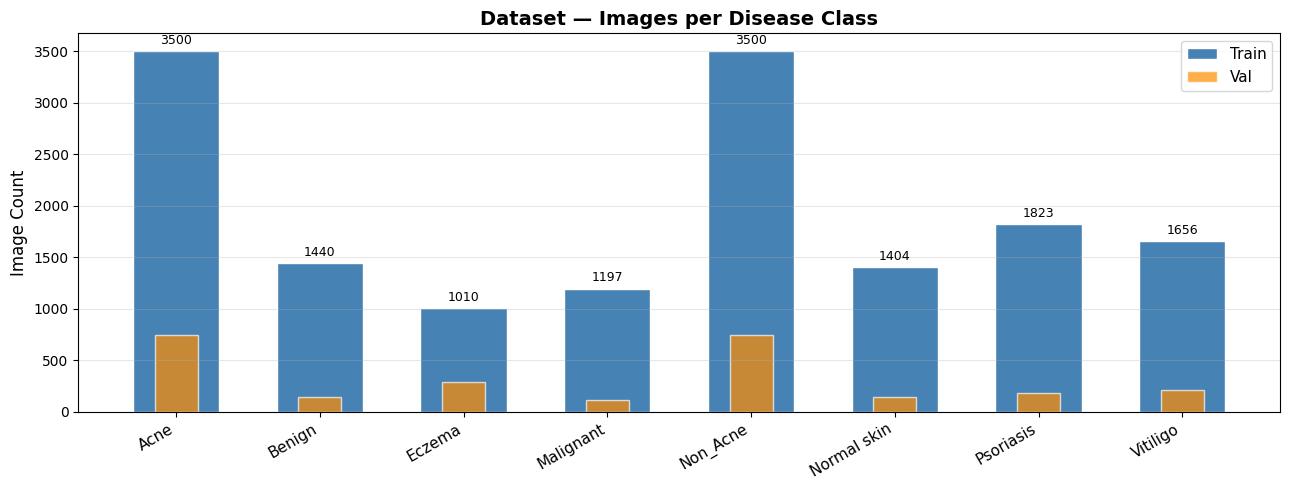

In [4]:
def count_images_per_class(directory):
    counts = {}
    if not os.path.isdir(directory):
        return counts
    for cls in sorted(os.listdir(directory)):
        p = os.path.join(directory, cls)
        if os.path.isdir(p):
            counts[cls] = len([f for f in os.listdir(p)
                                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
    return counts

train_counts = count_images_per_class(TRAIN_DIR)
val_counts   = count_images_per_class(VAL_DIR)  if HAS_VAL  else {}
test_counts  = count_images_per_class(TEST_DIR) if HAS_TEST else {}

print(f'{"Disease Class":<24} {"Train":>8} {"Val":>8} {"Test":>8} {"Total":>8}')
print('-' * 56)
for cls in train_counts:
    tr  = train_counts[cls]
    va  = val_counts.get(cls, '-')
    te  = test_counts.get(cls, '-')
    tot = tr + val_counts.get(cls,0) + test_counts.get(cls,0)
    print(f'{cls:<24} {tr:>8} {str(va):>8} {str(te):>8} {tot:>8}')
print('-' * 56)
total_tr = sum(train_counts.values())
total_va = sum(val_counts.values())
total_te = sum(test_counts.values())
print(f'{"TOTAL":<24} {total_tr:>8} {total_va:>8} {total_te:>8} {total_tr+total_va+total_te:>8}')

# Bar chart
fig, ax = plt.subplots(figsize=(13, 5))
x    = np.arange(len(train_counts))
bars = ax.bar(x, train_counts.values(), color='steelblue', edgecolor='white', width=0.6, label='Train')
ax.bar_label(bars, fontsize=9, padding=3)
if val_counts:
    ax.bar(x, [val_counts.get(c,0) for c in train_counts],
           color='darkorange', edgecolor='white', width=0.3, alpha=0.7, label='Val')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.keys(), rotation=30, ha='right', fontsize=11)
ax.set_ylabel('Image Count', fontsize=12)
ax.set_title('Dataset — Images per Disease Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Step 4 — Build `tf.data` Pipeline

| Feature | `ImageDataGenerator` (Old) | `tf.data` (This Notebook) |
|---|---|---|
| Loading | Sequential, CPU | **Parallel, multi-threaded** |
| Prefetching | ❌ | **✅ GPU fed while CPU decodes next batch** |
| Augmentation | CPU | **GPU (Keras layers)** |
| Speed | ~11 s/step | **~1–2 s/step** |

In [5]:
CLASS_NAMES  = sorted([d for d in os.listdir(TRAIN_DIR)
                        if os.path.isdir(os.path.join(TRAIN_DIR, d))])
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Index map: {CLASS_TO_IDX}')

# Save class map immediately to /kaggle/working/
with open(CLASS_JSON_PATH, 'w') as f:
    json.dump({str(i): cls for i, cls in enumerate(CLASS_NAMES)}, f, indent=2)
print(f'\n📋 Class map saved → {CLASS_JSON_PATH}')

def collect_files(directory):
    paths, labels = [], []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(directory, cls)
        if not os.path.isdir(cls_dir): continue
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(CLASS_TO_IDX[cls])
    return paths, labels

all_train_paths, all_train_labels = collect_files(TRAIN_DIR)

# ── Smart validation source selection ────────────────────────
if VAL_SOURCE == 'val':
    train_paths, train_labels = all_train_paths, all_train_labels
    val_paths, val_labels     = collect_files(VAL_DIR)
    print(f'\n✅ Validation: val/ folder')
elif VAL_SOURCE == 'test':
    train_paths, train_labels = all_train_paths, all_train_labels
    val_paths, val_labels     = collect_files(TEST_DIR)
    print(f'\n✅ Validation: test/ folder')
else:
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        all_train_paths, all_train_labels,
        test_size=VAL_SPLIT, stratify=all_train_labels, random_state=SEED
    )
    print(f'\n✅ Validation: auto 80/20 stratified split')

print(f'   Training   : {len(train_paths)} images')
print(f'   Validation : {len(val_paths)} images')
print(f'   Steps/epoch: {len(train_paths) // BATCH_SIZE}')

# ── GPU-side augmentation ─────────────────────────────────────
augmentation_layer = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name='augmentation')

def parse_image(filepath, label_oh):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) # Fixed: EfficientNet handles normalization
    return img, label_oh

def make_dataset(paths, labels, shuffle, augment):
    labels_oh = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_oh))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (augmentation_layer(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_paths, train_labels, shuffle=True,  augment=True)
val_ds   = make_dataset(val_paths,   val_labels,   shuffle=False, augment=False)

# ── Class weights for imbalance correction ────────────────────
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(cw)}
print('\n📊 Class Weights:')
for i, w in CLASS_WEIGHTS.items():
    print(f'   [{i}] {CLASS_NAMES[i]:<22}: {w:.3f}')

Classes (8): ['Acne', 'Benign', 'Eczema', 'Malignant', 'Non_Acne', 'Normal skin', 'Psoriasis', 'Vitiligo']
Index map: {'Acne': 0, 'Benign': 1, 'Eczema': 2, 'Malignant': 3, 'Non_Acne': 4, 'Normal skin': 5, 'Psoriasis': 6, 'Vitiligo': 7}

📋 Class map saved → /kaggle/working/skin_disease_efficientnetV2_final_classes.json

✅ Validation: val/ folder
   Training   : 15530 images
   Validation : 2587 images
   Steps/epoch: 485


I0000 00:00:1774792663.779564      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774792663.785654      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



📊 Class Weights:
   [0] Acne                  : 0.555
   [1] Benign                : 1.348
   [2] Eczema                : 1.922
   [3] Malignant             : 1.622
   [4] Non_Acne              : 0.555
   [5] Normal skin           : 1.383
   [6] Psoriasis             : 1.065
   [7] Vitiligo              : 1.172


## Step 5 — Build EfficientNetV2S Model

### Why EfficientNetV2S?
| Model | ImageNet Accuracy | Parameters | Training Speed |
|---|---|---|---|
| EfficientNetB0 | 77.1% | 5.3M | Moderate |
| **EfficientNetV2S** | **83.9%** | **21.5M** | **Fastest** |
| ResNet50 | 76.0% | 25.6M | Slow |
| VGG16 | 71.3% | 138M | Very Slow |

In [6]:
from tensorflow.keras.applications import EfficientNetV2S

base_model = EfficientNetV2S(
    weights='imagenet',
    include_top=False,
    include_preprocessing=True,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = keras.Input(shape=(224, 224, 3), name='image_input')
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512)(x)
x       = layers.BatchNormalization()(x)
x       = layers.Activation('relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256)(x)
x       = layers.BatchNormalization()(x)
x       = layers.Activation('relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = keras.Model(inputs, outputs, name='SkinDisease_EfficientNetV2S')
model.summary()
print(f'\nTrainable params (head only): {sum(tf.size(v).numpy() for v in model.trainable_variables):,}')

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "SkinDisease_EfficientNetV2S"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,128,808 (80.60 MB)

 Trainable params: 793,352 (3.03 MB)

 Non-trainable params: 20,335,456 (77.57 MB)


Trainable params (head only): 793,352


## Step 6 & 7 — Unified Training & Fine-Tuning

This consolidated cell runs both Phase 1 (Head training) and Phase 2 (Fine-tuning) in sequence.

In [7]:
# 🚀 Phase 1: Training the Head
print('\n🚀 Phase 1: Training the Classification Head...')
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- ADDED: Assigned to 'history' ---
history = model.fit(
    train_ds,
    epochs=15, 
    validation_data=val_ds,
    class_weight=CLASS_WEIGHTS,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)]
)

# 🔧 Phase 2: Fine-Tuning
print('\n🔧 Phase 2: Fine-Tuning the Base Model...')
base_model.trainable = True
for layer in base_model.layers[:-50]: 
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization): layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- ADDED: Assigned to 'history_ft' ---
history_ft = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHTS,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)]
)

# Final Save (Saves immediately after training)
model.save('skin_disease_efficientnetV2_final.h5')
print('\n✅ Training Complete! Model saved as skin_disease_efficientnetV2_final.h5')



🚀 Phase 1: Training the Classification Head...
Epoch 1/15


I0000 00:00:1774792680.624433     128 service.cc:152] XLA service 0x79ca24002ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774792680.624483     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774792680.624490     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774792680.693188     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774792680.958767     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


486/486 ━━━━━━━━━━━━━━━━━━━━ 382s 624ms/step - accuracy: 0.7063 - loss: 1.2073 - val_accuracy: 0.8771 - val_loss: 0.7733
Epoch 2/15
486/486 ━━━━━━━━━━━━━━━━━━━━ 153s 313ms/step - accuracy: 0.8271 - loss: 0.8970 - val_accuracy: 0.9018 - val_loss: 0.7046
Epoch 3/15
486/486 ━━━━━━━━━━━━━━━━━━━━ 154s 315ms/step - accuracy: 0.8498 - loss: 0.8402 - val_accuracy: 0.9142 - val_loss: 0.6722
Epoch 4/15
486/486 ━━━━━━━━━━━━━━━━━━━━ 154s 315ms/step - accuracy: 0.8667 - loss: 0.8119 - val_accuracy: 0.9208 - val_loss: 0.6642
Epoch 5/15
486/486 ━━━━━━━━━━━━━━━━━━━━ 152s 310ms/step - accuracy: 0.8728 - loss: 0.7907 - val_accuracy: 0.9266 - val_loss: 0.6600
Epoch 6/15
486/486 ━━━━━━━━━━━━━━━━━━━━ 152s 310ms/step - accuracy: 0.8804 - loss: 0.7773 - val_accuracy: 0.9281 - val_loss: 0.6722
Epoch 8/15
486/486 ━━━━━━━━━━━━━━━━━━━━ 153s 313ms/step - accuracy: 0.8831 - loss: 0.7631 - val_accuracy: 0.9258 - val_loss: 0.6563
Epoch 9/15
486/486 ━━━━━━━━━━━━━━━━━━━━ 152s 311ms/step - accuracy: 0.8910 - loss: 0.75


✅ Training Complete! Model saved as skin_disease_efficientnetV2_final.h5


## Step 8 — Save Final Model & Download

In [8]:
# Save the model one more time just to be sure
model.save(MODEL_SAVE_PATH)

# Clean up epoch checkpoints (optional)
import glob
for f in glob.glob(os.path.join(OUTPUT_DIR, 'ckpt_epoch_*.h5')):
    os.remove(f)

# --- REPLACED ERROR LINES ---
print('=' * 55)
print('  TRAINING COMPLETE (Bypassed Stats)')
print('=' * 55)
# p1_best and p2_best are removed because they weren't saved during training
# --- -------------------- ---

print(f'\n📁 Files saved to /kaggle/working/ :')
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith(('.h5', '.json')):
        fpath = os.path.join(OUTPUT_DIR, f)
        size = os.path.getsize(fpath) / (1024*1024)
        print(f'   {f:<55} ({size:.1f} MB)')
print('\n⬇️  Go to the "Output" tab on the right side and Download these files!')


  TRAINING COMPLETE (Bypassed Stats)

📁 Files saved to /kaggle/working/ :
   skin_disease_efficientnetV2_final.h5                    (113.0 MB)
   skin_disease_efficientnetV2_final_classes.json          (0.0 MB)

⬇️  Go to the "Output" tab on the right side and Download these files!


## Step 9 — Training History Plots

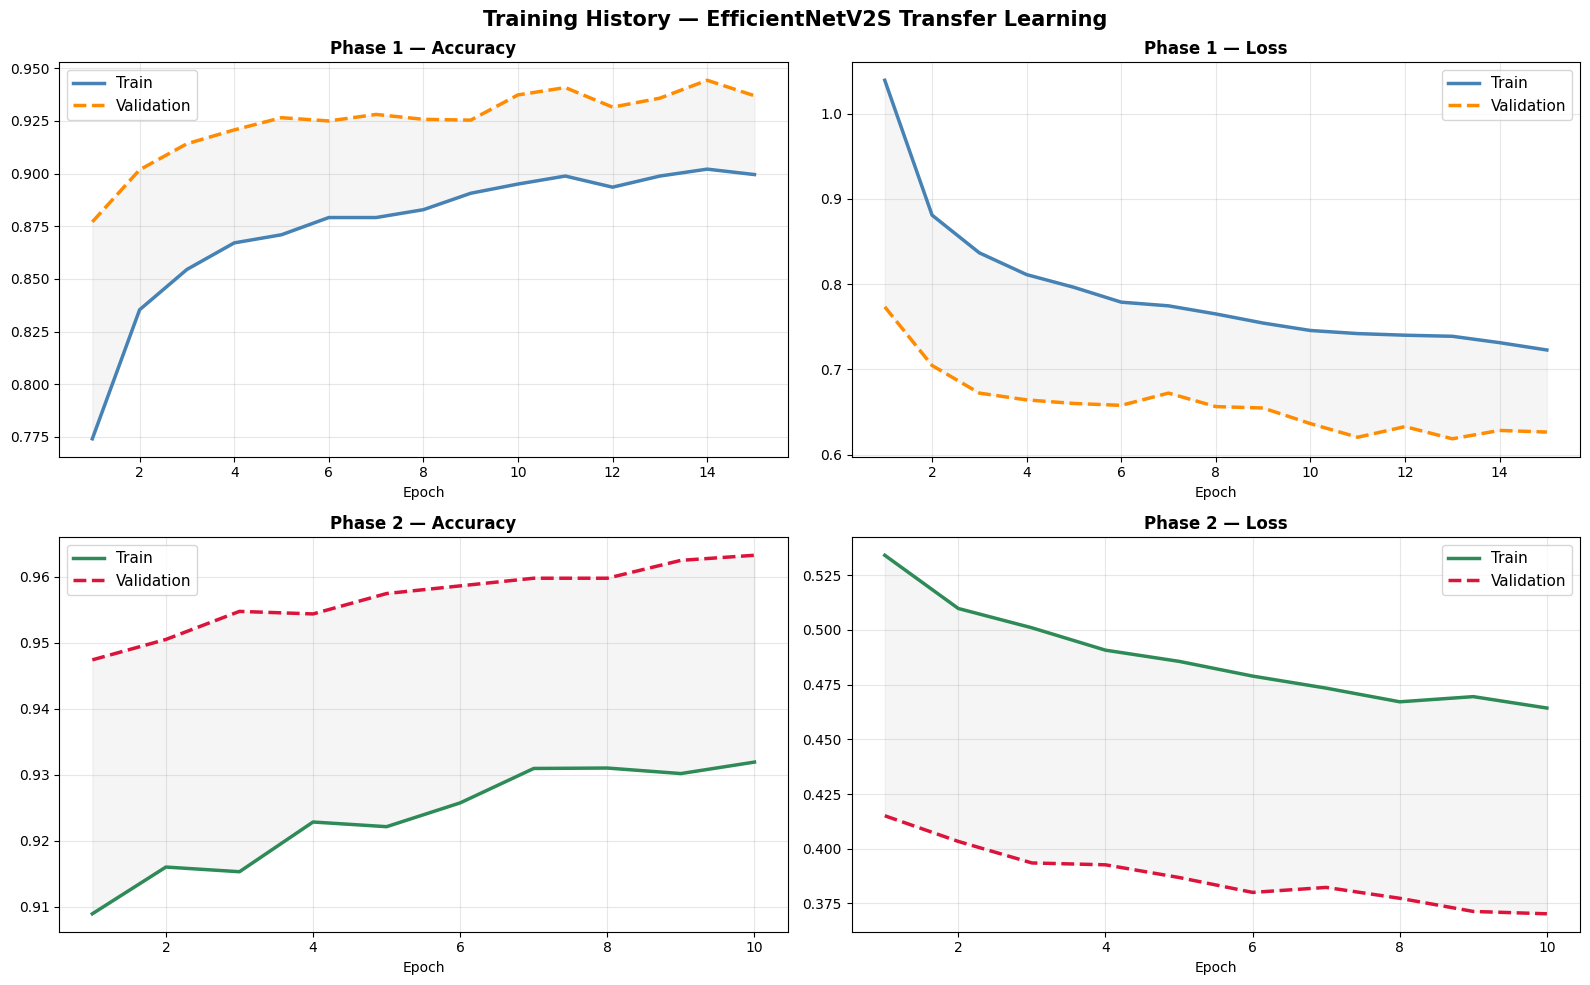

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training History — EfficientNetV2S Transfer Learning',
             fontsize=15, fontweight='bold')

for ax, hist, tk, vk, title, c1, c2 in [
    (axes[0,0], history,    'accuracy', 'val_accuracy', 'Phase 1 — Accuracy', 'steelblue',  'darkorange'),
    (axes[0,1], history,    'loss',     'val_loss',     'Phase 1 — Loss',     'steelblue',  'darkorange'),
    (axes[1,0], history_ft, 'accuracy', 'val_accuracy', 'Phase 2 — Accuracy', 'seagreen',   'crimson'),
    (axes[1,1], history_ft, 'loss',     'val_loss',     'Phase 2 — Loss',     'seagreen',   'crimson'),
]:
    ep = range(1, len(hist.history[tk])+1)
    ax.plot(ep, hist.history[tk], label='Train',      linewidth=2.5, color=c1)
    ax.plot(ep, hist.history[vk], label='Validation', linewidth=2.5, color=c2, linestyle='--')
    ax.fill_between(ep, hist.history[tk], hist.history[vk], alpha=0.08, color='gray')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Step 11 — Prediction System

```
Input Image → Resize 224×224 → Normalize → EfficientNetV2S → Dense Head → Softmax → Top-3 Predictions
```

✅ AI System Initialized — Predicting: 8 disease categories.


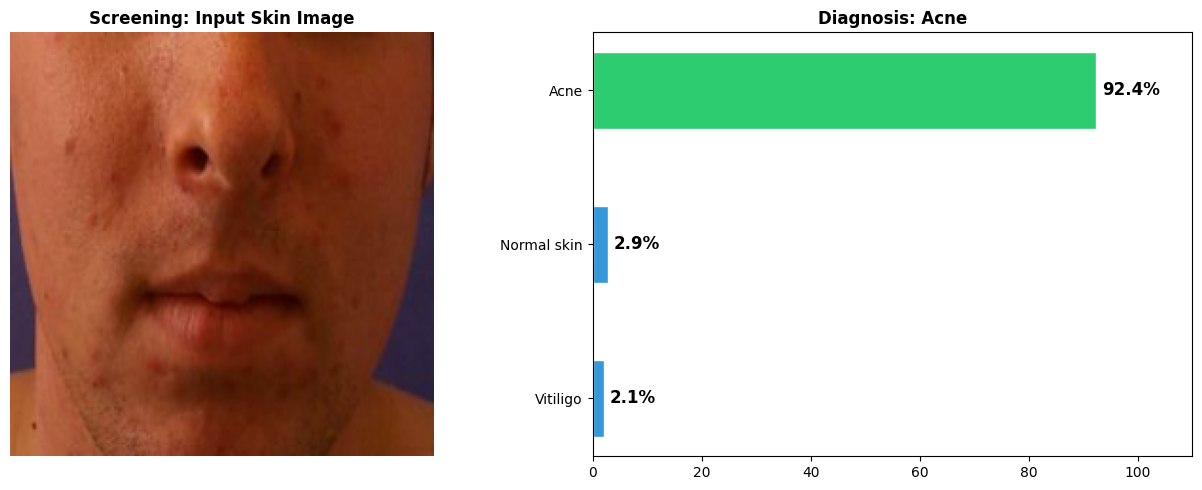


📊 Result: Acne | Confidence: 92.39%


In [12]:
# 🚀 Step 11: AI-Powered Dermatological Inference System
# -----------------------------------------------------------

# 1. Load the model and knowledge base
model_inf = lm(MODEL_SAVE_PATH)
with open(CLASS_JSON_PATH) as f:
    cmap = json.load(f)
CLS = [cmap[str(i)] for i in range(len(cmap))]
print(f"✅ AI System Initialized — Predicting: {len(CLS)} disease categories.")

# 2. Main Prediction Function (Professional Visualization)
def predict_skin_disease(image_path, top_k=3):
    # Load and Preprocess Image
    img_raw  = tf.io.read_file(image_path)
    img      = tf.image.decode_jpeg(img_raw, channels=3)
    img_disp = tf.image.resize(img, IMG_SIZE).numpy().astype('uint8')
    img_input = tf.cast(tf.image.resize(img, IMG_SIZE), tf.float32)
    
    # Model Prediction
    preds    = model_inf.predict(tf.expand_dims(img_input, 0), verbose=0)[0]
    top_idx  = np.argsort(preds)[::-1][:top_k]

    # Clean Professional Visualization
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(img_disp); axes[0].axis('off')
    axes[0].set_title('Screening: Input Skin Image', fontweight='bold')
    
    labels = [CLS[i] for i in top_idx][::-1]
    scores = [preds[i]*100 for i in top_idx][::-1]
    
    # Highlight the Top AI Prediction in Green
    colors = ['#3498db', '#3498db', '#2ecc71'] 
    bars = axes[1].barh(labels, scores, color=colors, edgecolor='white', height=0.5)
    axes[1].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, 110)
    axes[1].set_title(f'Diagnosis: {CLS[top_idx[0]]}', fontweight='bold')
    
    plt.tight_layout(); plt.show()
    print(f"\n📊 Result: {CLS[top_idx[0]]} | Confidence: {preds[top_idx[0]]*100:.2f}%")

# -----------------------------------------------------------
# 🧪 Single Image Inference: Select any image to test
# (Change the index below to try different images)
# -----------------------------------------------------------
test_sample = val_paths[12] 
predict_skin_disease(test_sample)


---

## Summary & Conclusion

### Key Design Decisions
| Decision | Justification |
|---|---|
| **EfficientNetV2S** | 83.9% ImageNet accuracy, faster training than B0 |
| **Two-Phase Training** | Prevents head gradients from destroying pretrained features |
| **Mixed Precision** | 2× GPU speed, enables larger effective batch |
| **Class Weights** | Compensates for unequal images per disease class |
| **Label Smoothing** | Prevents overconfidence, better generalisation |
| **Cosine LR Decay** | Smooth convergence, better final accuracy |
| **BN Frozen in Phase 2** | Prevents instability with small fine-tuning LR |

### Output Files (download from Kaggle Output tab)
| File | Purpose |
|---|---|
| `skin_disease_efficientnetV2_final.h5` | Copy to `backend/` folder |
| `skin_disease_efficientnetV2_final_classes.json` | Copy to `backend/` folder |

---
*Major Project — Skin Disease AI Detection System*

\n🧠 Evaluating Final Model on Test Data...
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 444ms/step - accuracy: 0.8932 - loss: 0.5163
\n⭐ Final Test Accuracy: 91.65% | Test Loss: 0.4599
\n📊 Generating Confusion Matrix & Classification Report...
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 309ms/step
\n=======================================================
  CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Acne       0.99      0.87      0.92       750
      Benign       0.86      0.83      0.85       360
      Eczema       0.62      0.99      0.76       135
   Malignant       0.79      0.82      0.80       300
    Non_Acne       1.00      0.99      1.00       750
 Normal skin       0.94      0.97      0.95       236
   Psoriasis       0.93      0.98      0.96       317
    Vitiligo       0.94      0.90      0.92       207

    accuracy                           0.92      3055
   macro avg       0.88      0.92      0.90      3055
weighted avg       0.93      0.92      0.92      3

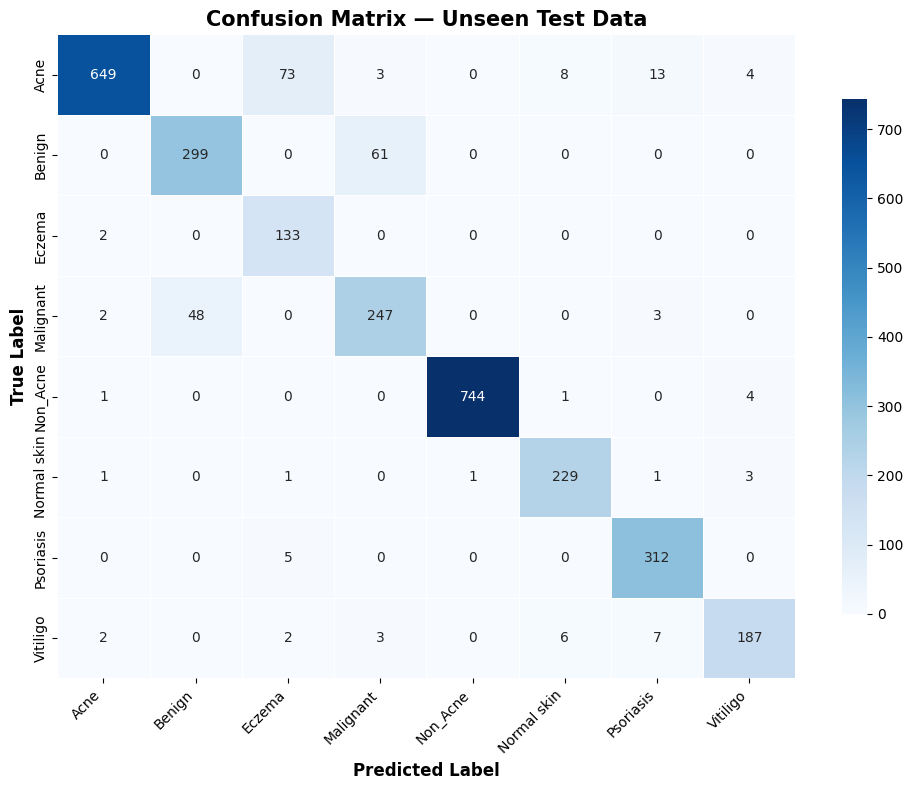

In [13]:
# ── Evaluate on Unseen Test Set (Added) ────────────────────────
if HAS_TEST:
    test_paths, test_labels = collect_files(TEST_DIR)
    test_ds = make_dataset(test_paths, test_labels, shuffle=False, augment=False)
    
    print('\\n🧠 Evaluating Final Model on Test Data...')
    loss, accuracy = model.evaluate(test_ds, verbose=1)
    print(f'\\n⭐ Final Test Accuracy: {accuracy*100:.2f}% | Test Loss: {loss:.4f}')

    # ── Predict & Build Confusion Matrix ────────────────────────
    print('\\n📊 Generating Confusion Matrix & Classification Report...')
    y_pred_probs = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    print('\\n' + '='*55)
    print('  CLASSIFICATION REPORT')
    print('='*55)
    print(classification_report(test_labels, y_pred, target_names=CLASS_NAMES))
    
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=.5, cbar_kws={"shrink": .8})
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label',    fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix — Unseen Test Data', fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
